### Import Packages
The following code block imports the custom Cytoripple constants, calculation, and plotting functions.
<br>
We also adjust the plotting resolution (dots per inch) to a higher resolution (though users may custom adjust this parameter as it can slow down plotting).

In [1]:
# Imports (may have to use Sys to connect to where you have downloaded CytoRipple)
# > Private packages
from image_io import *
from calculations import *
from consts import *
from plotting import *
# > Public packages
import torch

In [2]:
# Adjust Plot Resolution
# > If in IPython notebook utilize higher resolution 'retina' format
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')
# > Adjust the resolution (dots-per-inch, DPI)
from matplotlib import rcParams
rcParams['figure.dpi'] = 100

### Read in Segmentation and Intensities File
We provide example files for analysis in the following repository (not hosted on GitHub due to their large size). We walk through an example with the MIBI data type here. Not all user image formats may be covered by the current image processing in the package. We provide the following methods:
| Function | Image Type |
|---|---|
| `create_marker_list_xeniumcodex` | Xenium |
| `create_marker_list_xeniumcodex` | Codex |
| `create_marker_list_mibiv1`| MIBI |
| `create_marker_list_mibiv2` | MIBI (Backup) |

If your image format is not covered above or incompatible with the provided functions please either:
* Supply your marker list to the `marker_list` variable (e.g. `[ProteinA, ProteinB, ...])`.
* Provide a custom function to derive this marker list to replace `create_marker_list...`.
* Write in the index of your marker of interest to the `image_stack_index` variable (e.g. `3`).

Intensities are automatically move to GPU for faster computation (if one is available). To disable this, replace `DEVICE` with a torch device of your interest e.g. `torch.device('cpu')` for CPU and `torch.device('mps')` for Apple Silicon.

In [3]:
# Read in the segmentation and marker intensities file
# > Define file name
segmentation_file = '/PATH/TO/MIBI/segmentation.tif'
intensities_file = '/PATH/TO/MIBI/intensities.tiff'
# > Process data in files
segmentation_imstack, marker_imstack = load_data(segmentation_file, intensities_file)
segmentation_dict = create_segmentation_dict(segmentation_imstack)
# > Define marker of interest and locate in image stack
marker_of_interest = 'Vimentin'
marker_list = create_marker_list_mibiv2(intensities_file)
image_stack_index = marker_list.index(marker_of_interest)
# > Retrieve intensities for the marker of interest
intensities = marker_imstack[0][image_stack_index]
# > Set accelerator device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
intensities_acc = torch.tensor(intensities, device=device, dtype=torch.float32)

### Vector Computation
After we have read in and processed the image segmentation and intensities we compute the vectors (based on intracellular protein intensity distribution) for all segmented objects (e.g. cells). These are utilized to generate a vector field for the entire image. These vectors can contain random noise due to inherent biological stochasticity or technical noise. To reduce these, potentially uninformative, covariates, we smooth the vector field. We constrain this smoothing via the following parameters. Defaults are supplied in the `consts.py` file but these can all be changed to the user's preference. We supply descriptions of the variables below:
| Parameter | Description |
|---|---|
| `min_magnitude` | Minimum unscaled vector magnitude to consider as valid (default = 1) |
| `smooth_iters` | Number of rounds of vector field smoothing to perform (default = 1) |
| `smooth_dist_limit_pixel` | Only cells within this radius will be considered in smoothing (default = 90µm) |

**Change the `PIXEL_TO_MICRON` variable in the `consts.py` file to fit your image type (e.g. 0.390625 for MIBI and 0.2125 for Xenium/CODEX).**

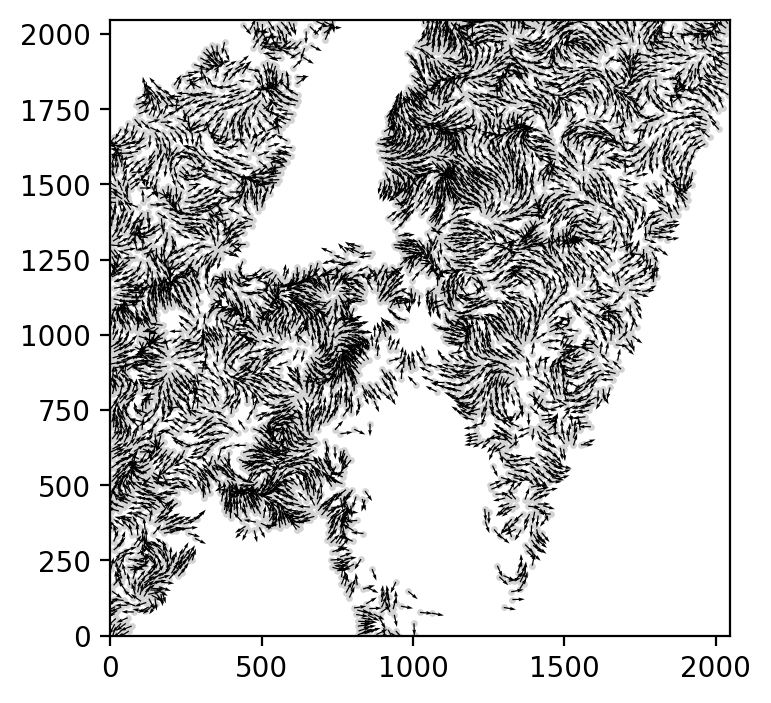

In [4]:
# Generate smoothed vectors
vectors = generate_vector_field(segmentation_dict, intensities_acc, device)
smoothed_vectors = smooth_vector_field(vectors,
                                       min_magnitude=MIN_VECTOR_MAGNITUDE,
                                       smooth_iters=SMOOTH_ITERS,
                                       smooth_dist_limit_pixel=SMOOTH_DIST_LIMIT_PIXEL)
# Visualize smoothed vectors
fig = plot_vectors(smoothed_vectors, figsize=[4, 4])

## Curl and Divergence Computation
Vectors can naturally take on curl-like (positive vs. negative simply denotes clockwise vs. counterclockwise) patterns or display divergence-like behavior (with negative values indicating convergence). We provide functions to calculate for these across the provided image. These curl and divergence/convergence metrics can be utilized for downstream analyses (e.g. enrichment and hard/soft clustering).

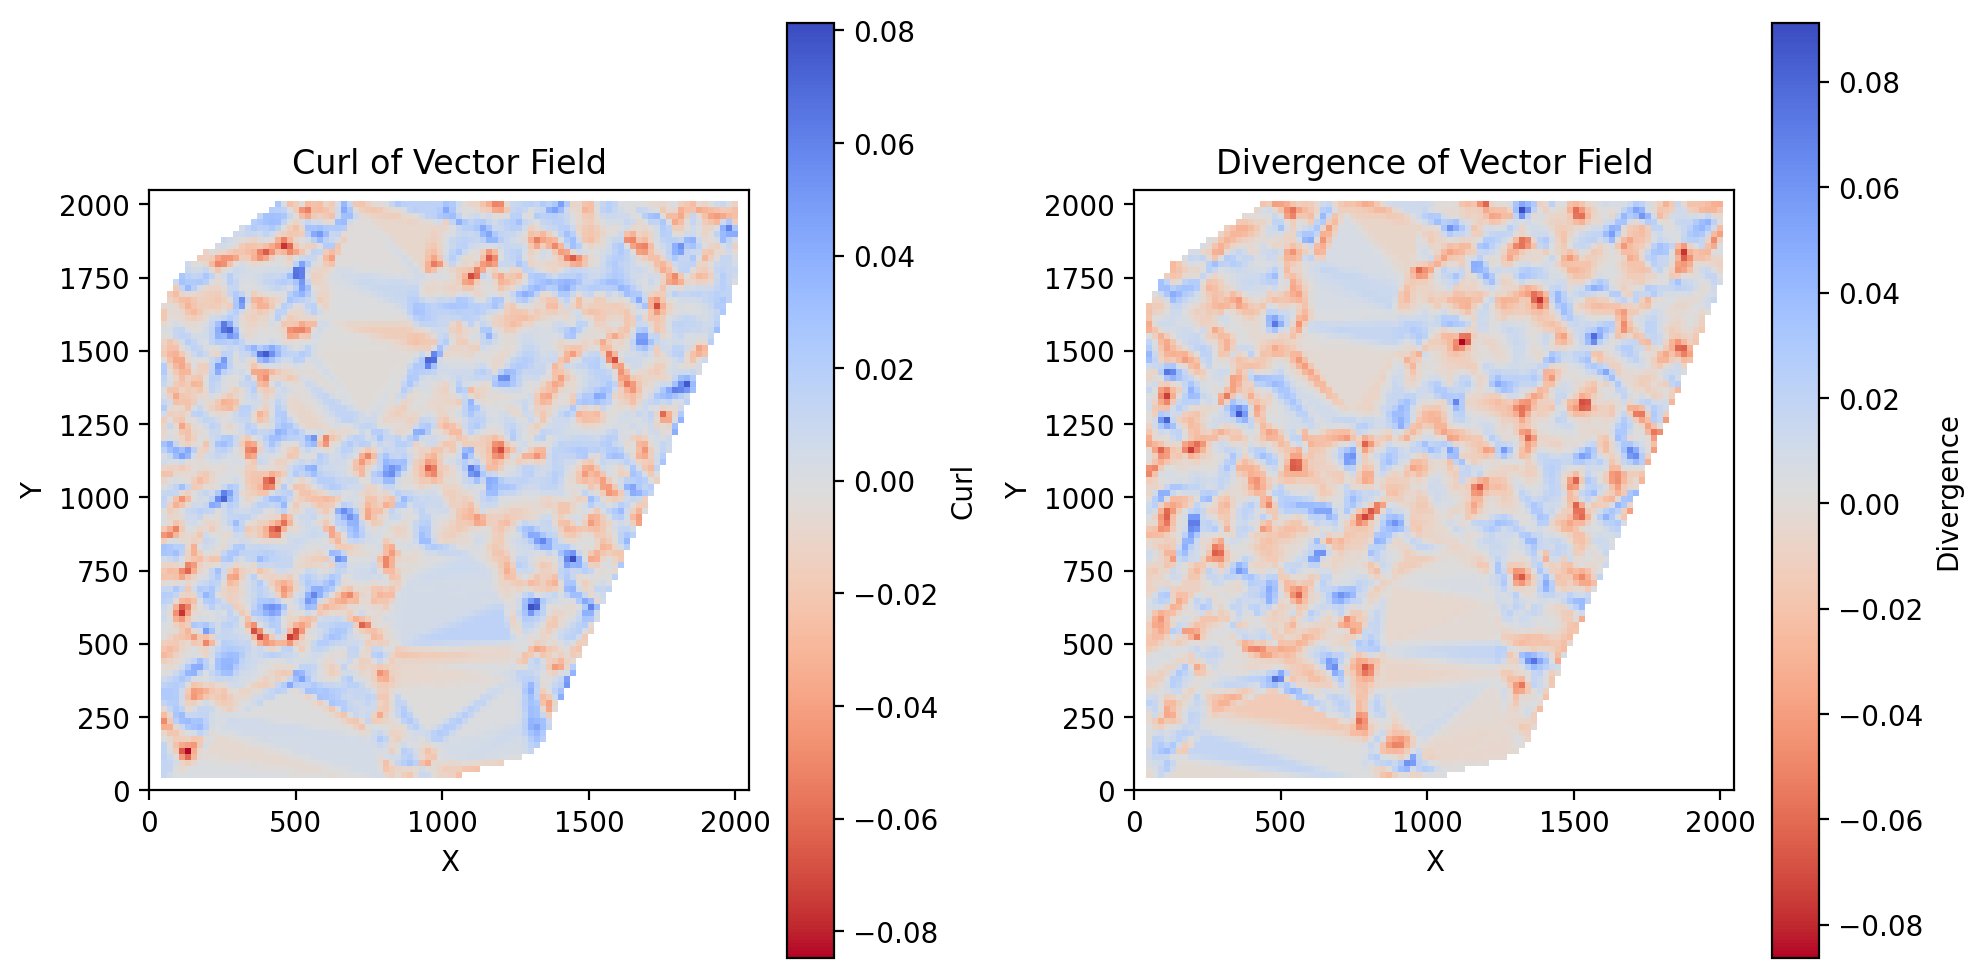

In [5]:
# Calculate curl and divergence metrics
XI, YI, curl, divergence = calculate_curl_and_divergence(smoothed_vectors)
# Visualize calculated metrics
fig = plot_curl_and_divergence(XI, YI, curl, divergence, cmap='coolwarm_r', figsize=[10, 5])